# Visualizing reproducibility and robustness

`reproducibility` and `robustness` don't compare individual hypotheses --
they reduce a *whole run* (all its hypotheses, mean-pooled into one vector, or
just the rank-1 hypothesis, depending on `config.multi_run_comparison`) down
to a single point, then compare those run-level points to each other:

- **reproducibility**: base run vs. repeat run(s) of the *identical* prompt --
  high similarity = the tool reasons consistently; low = it's noisy.
- **robustness**: base run vs. a *reworded* (paraphrased) prompt's run -- high
  similarity = genuine reasoning survives rewording; low = surface
  pattern-matching that breaks under paraphrase.

This notebook projects those run-level vectors into 2D with PCA (same
technique as the other notebooks, same caveat: it's for intuition, the real
metrics use full-dimensional cosine similarity) so you can see how tightly
the repeat/reworded runs cluster around the base run.

Everything here reuses the real `run_vector` helper and the real
`Reproducibility`/`Robustness` metric classes directly -- nothing about the
comparison is reimplemented.


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "benchmarking_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from benchmarking_pipeline.axes.quality._shared import run_vector
from benchmarking_pipeline.axes.quality.reproducibility import Reproducibility
from benchmarking_pipeline.axes.quality.robustness import Robustness
from benchmarking_pipeline.core.config import RunConfig
from benchmarking_pipeline.core.context import Context
from benchmarking_pipeline.core.models import RunBundle, Tool
from benchmarking_pipeline.io.tool_adapters.file_adapter import FileAdapter
from benchmarking_pipeline.services.embeddings import SPECTER2, SentenceTransformerEmbedding, cosine_similarity

# --- Config ---
TOOL_NAME = "pknowlesi-hypothesis-tool"
PROMPT = "artemisinin-resistant Plasmodium knowlesi therapeutic hypotheses"
BASE_PATH = "data/captures/pknowlesi_base.json"
REPEAT_PATHS = ["data/captures/pknowlesi_repeat.json"]
# {perturbation type -> [paths]}; "reword" is scored, anything else (e.g.
# kb_removal) is reported for interpretation only -- see robustness.py.
PERTURBATION_PATHS = {"reword": ["data/captures/pknowlesi_reworded.json"]}

tool = Tool(name=TOOL_NAME)
base = FileAdapter(tool=tool, output_path=BASE_PATH).run(prompt=PROMPT)
repeats = [FileAdapter(tool=tool, output_path=p).run(prompt=PROMPT) for p in REPEAT_PATHS]
perturbations = []
for ptype, paths in PERTURBATION_PATHS.items():
    for p in paths:
        run = FileAdapter(tool=tool, output_path=p).run(prompt=PROMPT)
        run.metadata["perturbation"] = ptype
        perturbations.append(run)

bundle = RunBundle(base=base, repeats=repeats, perturbations=perturbations)
print(f"base: {len(base.outputs)} hypotheses, {len(repeats)} repeat(s), {len(perturbations)} perturbation(s)")


base: 3 hypotheses, 1 repeat(s), 1 perturbation(s)


## Run the real metrics


In [2]:
embed = SentenceTransformerEmbedding(SPECTER2)
ctx = Context(config=RunConfig(), embeddings=embed)

repro_result = Reproducibility().score(bundle, ctx)
robust_result = Robustness().score(bundle, ctx)

print(f"reproducibility: {repro_result.score} ({repro_result.anchor})")
print(f"  {repro_result.evidence}")
print()
print(f"robustness: {robust_result.score} ({robust_result.anchor})")
print(f"  {robust_result.evidence}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

reproducibility: 0.993 (highly reproducible)
  {'n_runs': 2, 'comparison_unit': 'whole_set', 'mean_pairwise_similarity': 0.993, 'variance': 0.0, 'embedding_model': 'st:allenai/specter2_base'}

robustness: 0.9884 (stable under rewording)
  {'comparison_unit': 'whole_set', 'reword_stability': 0.9884, 'similarity_by_perturbation': {'reword': [0.9884]}, 'embedding_model': 'st:allenai/specter2_base', 'note': 'kb_removal similarities reported for interpretation, not scored'}


## Project run-level vectors into 2D

One point per run (not per hypothesis) -- the base run, each repeat, each
perturbation. Distance from the base point is what the metrics are actually
measuring; the dashed lines are labeled with the real cosine similarity to
base, so you don't have to eyeball 2D distance to know the real number.


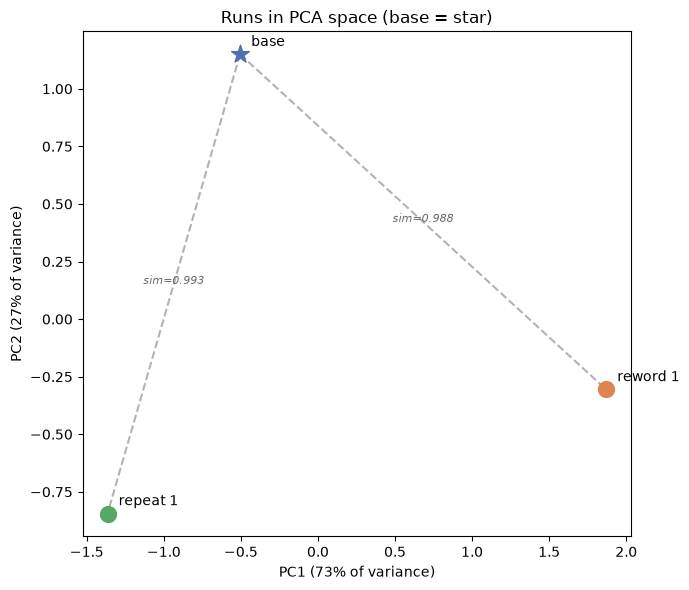

In [3]:
runs = [("base", base, None)]
for i, r in enumerate(repeats):
    runs.append((f"repeat {i+1}", r, "repeat"))
seen_of_type = {}
for r in perturbations:
    ptype = r.metadata["perturbation"]
    seen_of_type[ptype] = seen_of_type.get(ptype, 0) + 1
    runs.append((f"{ptype} {seen_of_type[ptype]}", r, ptype))

vectors = [run_vector(r, ctx) for _, r, _ in runs]
labels = [label for label, _, _ in runs]
kinds = [kind for _, _, kind in runs]

base_vec = vectors[0]
similarities = [cosine_similarity(base_vec, v) for v in vectors]

pca = PCA(n_components=2)
coords = pca.fit_transform(np.vstack(vectors))

color_by_kind = {None: "#4C72B0", "repeat": "#55A868", "reword": "#DD8452", "kb_removal": "#8172B2"}

fig, ax = plt.subplots(figsize=(7, 6))
for i, (label, kind) in enumerate(zip(labels, kinds)):
    ax.scatter(*coords[i], s=180 if kind is None else 130,
              color=color_by_kind.get(kind, "#8C8C8C"),
              marker="*" if kind is None else "o", zorder=3)
    ax.annotate(label, coords[i], textcoords="offset points", xytext=(8, 6), fontsize=10)
    if kind is not None:
        ax.plot(*zip(coords[0], coords[i]), "--", color="gray", alpha=0.6, zorder=1)
        mid = (coords[0] + coords[i]) / 2
        ax.annotate(f"sim={similarities[i]:.3f}", mid, fontsize=8, color="dimgray",
                   ha="center", style="italic")

ax.set_title("Runs in PCA space (base = star)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
plt.tight_layout()
plt.show()


## The raw numbers, since a handful of runs can look identical in a 2D plot

With only one repeat and one reworded run, the PCA plot above has very few
points to show real spread -- more repeats/perturbations would make it a
genuinely richer picture. This bar chart shows the same cosine similarities
numerically, which stay precise regardless of how many points there are to
plot.


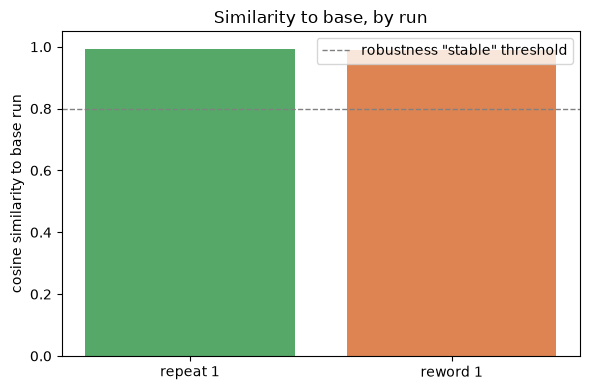

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
non_base = [(label, sim, kind) for label, sim, kind in zip(labels[1:], similarities[1:], kinds[1:])]
bar_colors = [color_by_kind.get(kind, "#8C8C8C") for _, _, kind in non_base]
ax.bar([label for label, _, _ in non_base], [sim for _, sim, _ in non_base], color=bar_colors)
ax.axhline(0.8, color="gray", ls="--", lw=1, label="robustness \"stable\" threshold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("cosine similarity to base run")
ax.set_title("Similarity to base, by run")
ax.legend()
plt.tight_layout()
plt.show()
